<a href="https://colab.research.google.com/github/dldustj0715/machine_learning/blob/main/week02/wine_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Regression — Alcohol Prediction

`wine.csv`의 연속형 변수인 **Alcohol**을 target으로 설정하여 회귀 분석을 수행합니다.

분류 정답 열인 `Wine`은 입력 변수에서 제외합니다.

사용 모델:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. SVR

각 모델에서 **MSE**와 **RMSE**를 모두 출력합니다.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wine.csv")
df


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


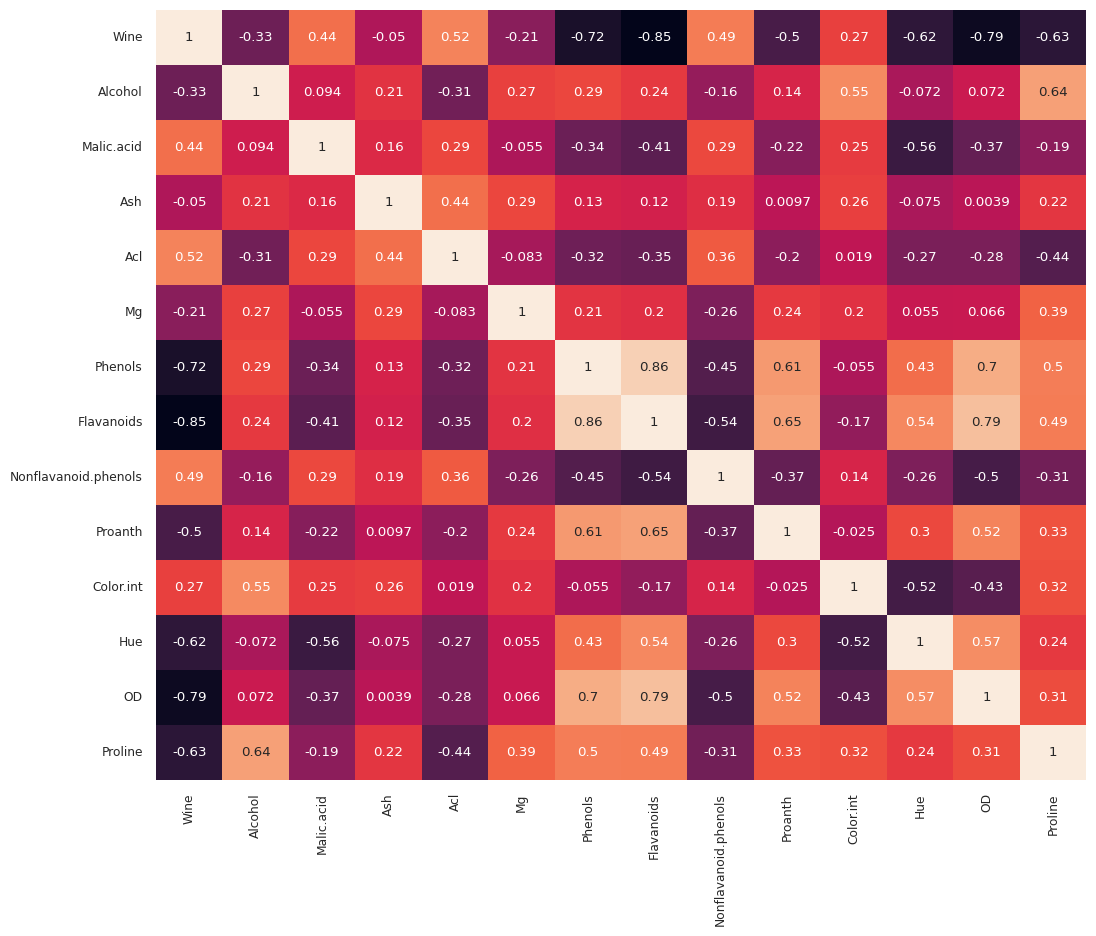

In [4]:
# 상관 관계 행렬
df_corr = df.corr()

plt.figure(figsize=(12,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()


## 입력 데이터(X)와 target(y) 설정

- 예측할 값: `Alcohol`
- 분류용 정답 열인 `Wine`은 입력 변수에서 제외합니다.


In [5]:
X = df.drop(['Alcohol', 'Wine'], axis=1)
X.head()


,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [6]:
y = df['Alcohol']
y.head()


,Alcohol
0,14.23
1,13.20
2,13.16
3,14.37
4,13.24


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=12
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(142, 12) (142,)
(36, 12) (36,)


## 1. Linear Regression


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

ly_preds = model.predict(X_test)

mse = mean_squared_error(y_test, ly_preds)
rmse = np.sqrt(mse)

print("평균제곱오차(MSE):", mse)
print("평균제곱근오차(RMSE):", rmse)


평균제곱오차(MSE): 0.2933576216695043
평균제곱근오차(RMSE): 0.541624982501273


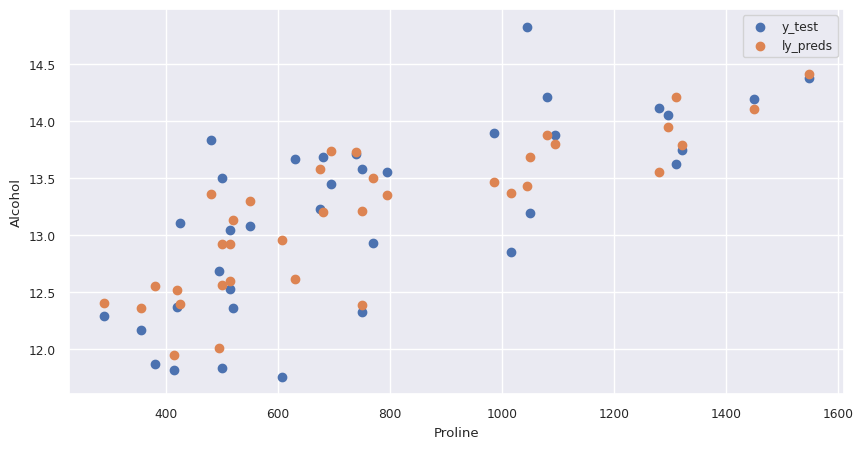

In [9]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Proline'], y_test, label='y_test')
plt.scatter(X_test['Proline'], ly_preds, label='ly_preds')
plt.xlabel('Proline')
plt.ylabel('Alcohol')
plt.legend()
plt.show()


## 2. Decision Tree Regression


In [10]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=12)
model.fit(X_train, y_train)

dy_preds = model.predict(X_test)

mse = mean_squared_error(y_test, dy_preds)
rmse = np.sqrt(mse)

print("평균제곱오차(MSE):", mse)
print("평균제곱근오차(RMSE):", rmse)


평균제곱오차(MSE): 0.42712500000000037
평균제곱근오차(RMSE): 0.6535480089480805


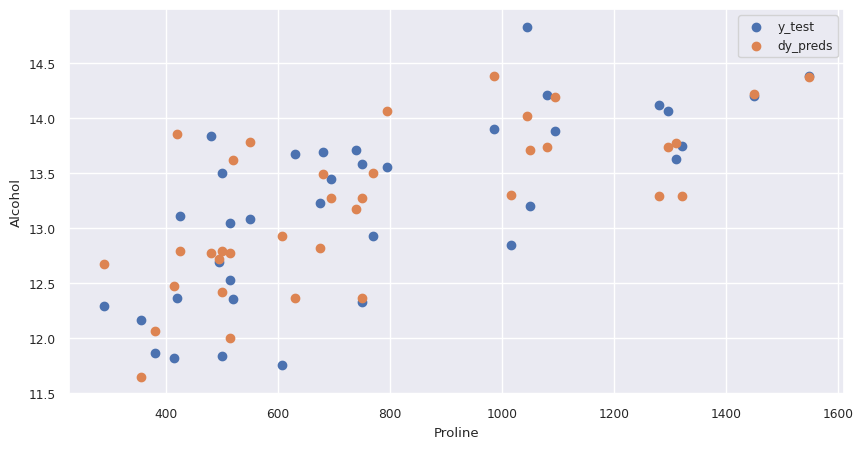

In [11]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Proline'], y_test, label='y_test')
plt.scatter(X_test['Proline'], dy_preds, label='dy_preds')
plt.xlabel('Proline')
plt.ylabel('Alcohol')
plt.legend()
plt.show()


## 3. Random Forest Regression


In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=12)
model.fit(X_train, y_train)

ry_preds = model.predict(X_test)

mse = mean_squared_error(y_test, ry_preds)
rmse = np.sqrt(mse)

print("평균제곱오차(MSE):", mse)
print("평균제곱근오차(RMSE):", rmse)


평균제곱오차(MSE): 0.2701626125000009
평균제곱근오차(RMSE): 0.5197716926690034


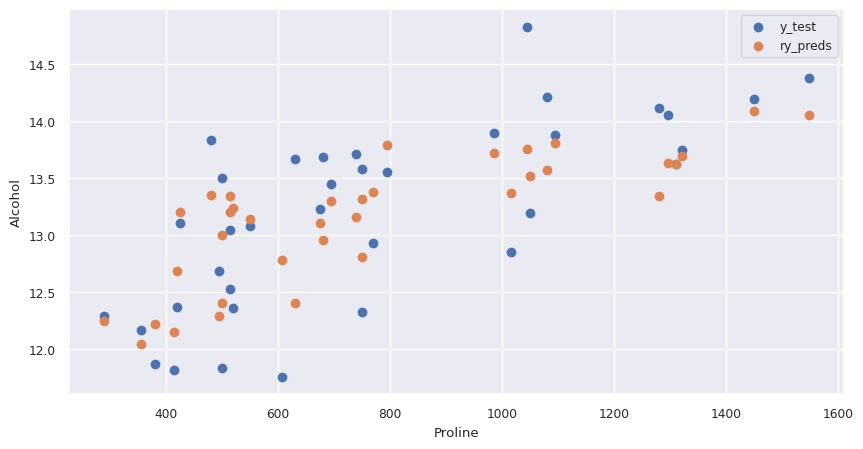

In [13]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Proline'], y_test, label='y_test')
plt.scatter(X_test['Proline'], ry_preds, label='ry_preds')
plt.xlabel('Proline')
plt.ylabel('Alcohol')
plt.legend()
plt.show()


## 4. SVR


In [14]:
from sklearn.svm import SVR

model = SVR(kernel='linear')
model.fit(X_train, y_train)

sy_preds = model.predict(X_test)

mse = mean_squared_error(y_test, sy_preds)
rmse = np.sqrt(mse)

print("평균제곱오차(MSE):", mse)
print("평균제곱근오차(RMSE):", rmse)


평균제곱오차(MSE): 0.30759157236861173
평균제곱근오차(RMSE): 0.5546093871984243


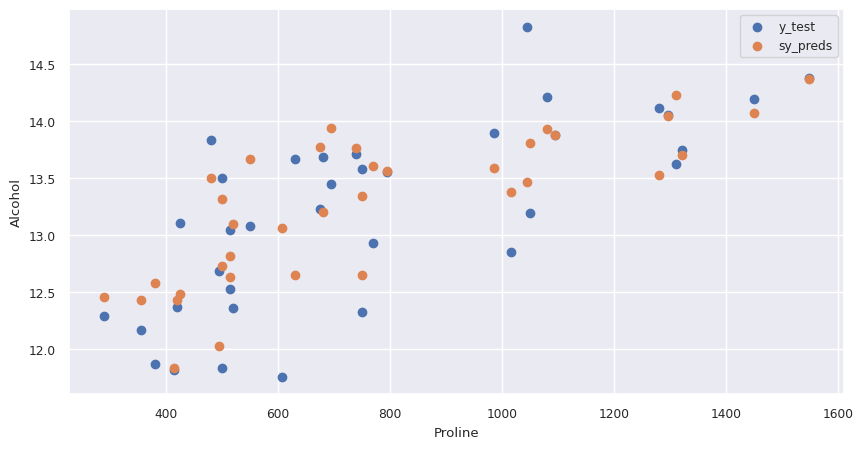

In [15]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Proline'], y_test, label='y_test')
plt.scatter(X_test['Proline'], sy_preds, label='sy_preds')
plt.xlabel('Proline')
plt.ylabel('Alcohol')
plt.legend()
plt.show()
